# 02c — Diagnostic 3: a stratified Neotropical training sample

Our step-2 model is trained on Colombia only. Diagnostic 3 asks whether training
scope (pantropical in the paper vs Colombia here) explains why our model predicts
far less regrowth than the authors' map. This notebook builds a Neotropical
training sample with **the same definitions as `02b`**; `03d_transfer_test`
uses it.

**Domain.** RESOLVE 2017 biomes 1–3 (tropical and subtropical moist, dry and
coniferous forests), latitude −25…25°, longitude −120…−30° (the Americas).

**Equal-area stratification.** HEALPix depth-5 cells (NESTED, WGS84, about
200 km) are described on a 0.05° lattice: domain area, sub-region and biome.
Each cell is assigned to the stratum (sub-region × biome) that covers most of its
domain area. Cells with at least `MIN_COVER` of their area in the domain are
eligible. `N_CELLS` cells are drawn at random: one per stratum first, the rest
proportional to stratum area. Sub-regions come from an explicit RESOLVE
ecoregion → sub-region table (below).

**Labels and pixels (as in `02b`, on the 30 m Hansen lattice, pixel-centre rule).**
Class 1 = domain ∩ Fagan et al. (2022) `regrowth` polygons; class 0 = domain −
forest 2000 − ESA CCI 2000 classes 150–153, 190, 200–202, 210 − all Fagan polygons.
Forest = Hansen v1.13 tree cover 2000 ≥ 30 %. Pixels are drawn by Bernoulli
sampling with inclusion probability ∝ exact pixel area, with per-cell rates, and
then capped at `CAP_PER_CLASS` points per class and cell, so that regrowth
hotspots do not dominate.

**Predictors (2000; the Neotropical sample is used for training only).** Forest
density (1 km-radius disk) and distance to forest (Euclidean, capped at 25 km),
computed on 1° tiles with a 0.25° margin exactly as in `02b`; SoilGrids v2017
OCDENS / PHIHOX top 30 cm; bioclim PC1–PC4 with the **existing** PCA loadings
(`data/clean/bioclim_pca_loadings.csv`, not refitted); ESA CCI 2000 land cover
in the same 31 → 11 classes; biome.

**Disk.** Only point values are kept. Hansen tree-cover tiles are downloaded one
group at a time and deleted after use (the Colombian tiles in `data/raw/hansen`
are reused and kept); SoilGrids and ESA CCI are read remotely at the points;
WorldClim is read from the zip already in `data/raw`.

**Smoke mode** (`SMOKE=1`): three cells (one per sub-region, including the
Colombian smoke window), two 1° tiles per cell, cap 150; outputs in
`data/clean_smoke/` and `figures/smoke/`.

In [1]:
import base64
import json
import multiprocessing as mp
import os
import shutil
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
import shapely
import xarray as xr
from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix, vertices
from matplotlib.collections import PolyCollection
from osgeo import gdal, ogr
from pyproj import Geod
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.windows import Window, from_bounds
from scipy import ndimage, signal

gdal.UseExceptions()
ogr.UseExceptions()
for k, v in dict(GDAL_HTTP_MULTIRANGE="YES", GDAL_HTTP_MAX_RETRY="10", GDAL_HTTP_RETRY_DELAY="5",
                 CPL_VSIL_CURL_CHUNK_SIZE="4194304", GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR").items():
    gdal.SetConfigOption(k, v)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
RAW = Path("../data/raw")
SMOKE = os.environ.get("SMOKE", "0") == "1"
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
TILE_CACHE = CLEAN / "neotropics_tiles"
HANSEN_TMP = RAW / "hansen_tmp_neotropics"
for d in (CLEAN, FIGURES, TILE_CACHE):
    d.mkdir(parents=True, exist_ok=True)

# identical to 02b
RES = 0.00025
TILE_DEG, MARGIN_PX = 1, 1000
TILE_PX = int(round(TILE_DEG / RES))
TREE_THRESHOLD = 30
DENSITY_RADIUS_M = 1000.0
DIST_CAP_M = 25_000.0
SEED = 20261003
ESA_EXCL_TRAIN = [150, 151, 152, 153, 190, 200, 201, 202, 210]
FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]

# diagnostic 3
REGION_BBOX = (-120.0, -25.0, -30.0, 25.0)
CELL_DEPTH = 5
LATTICE_RES = 0.05
MIN_COVER = 0.25
N_CELLS = 3 if SMOKE else 48
CAP_PER_CLASS = 150 if SMOKE else 1000
OVERSAMPLE1, OVERSAMPLE0 = 3.0, 30.0  # expected candidates / cap: class 1 per regrowth pixel, class 0 per domain pixel
VAL_SHARE = 0.25
MIN_FREE_GB = 10.0
N_WORKERS = int(os.environ.get("N_WORKERS", 4 if SMOKE else min(12, os.cpu_count() or 1)))
print(f"smoke={SMOKE} cells={N_CELLS} cap={CAP_PER_CLASS} workers={N_WORKERS}")

WGS84_A, WGS84_F = 6378137.0, 1 / 298.257223563
E2 = WGS84_F * (2 - WGS84_F)
EC = np.sqrt(E2)


def _q(phi: np.ndarray) -> np.ndarray:
    s = np.sin(phi)
    return (1 - E2) * (s / (1 - E2 * s * s) - np.log((1 - EC * s) / (1 + EC * s)) / (2 * EC))


def area_ellipsoid(lat_top: np.ndarray, res: float = RES) -> np.ndarray:
    """Exact WGS84 area (m²) of a res × res lon/lat cell whose top edge is at lat_top (02b, res as argument)."""
    return WGS84_A**2 / 2 * np.radians(res) * (_q(np.radians(lat_top)) - _q(np.radians(lat_top - res)))


def metres_per_degree(lat: float) -> tuple[float, float]:
    phi = np.radians(lat)
    s2 = np.sin(phi) ** 2
    m = WGS84_A * (1 - E2) / (1 - E2 * s2) ** 1.5
    n = WGS84_A / np.sqrt(1 - E2 * s2)
    return float(np.radians(1) * m), float(np.radians(1) * n * np.cos(phi))


def free_gb(path: Path = RAW) -> float:
    return shutil.disk_usage(path).free / 1e9


HP_CELL_AREA = 4 * np.pi * (WGS84_A**2 / 2 * _q(np.pi / 2)) / (12 * 4**CELL_DEPTH)  # authalic sphere, equal-area cells
print(f"free disk {free_gb():.1f} GB; HEALPix depth-{CELL_DEPTH} cell area {HP_CELL_AREA / 1e6:,.0f} km²")

smoke=False cells=48 cap=1000 workers=12
free disk 22.7 GB; HEALPix depth-5 cell area 41,509 km²


## 1. Domain and sub-regions (RESOLVE 2017)

Sub-regions from the RESOLVE ecoregion names. Ecoregions that fit none of the six
named sub-regions (Chocó–Pacific coast, Caribbean coast of South America, Llanos
edge) form a seventh stratum, "Chocó-Pacific and northern lowlands", so that
every domain pixel belongs to a sub-region. The Guiana Shield is grouped with the
Amazon. "Cerrado/Chaco edge" holds the dry forests of the South American dry
diagonal (Cerrado and Chaco themselves are savanna biomes and outside the domain).

In [3]:
SUBREGIONS = {
    "Mesoamerica": [
        "Central American Atlantic moist forests", "Central American montane forests", "Chiapas montane forests",
        "Chimalapas montane forests", "Costa Rican seasonal moist forests", "Eastern Panamanian montane forests",
        "Isthmian-Atlantic moist forests", "Isthmian-Pacific moist forests", "Oaxacan montane forests",
        "Pantanos de Centla", "Petén-Veracruz moist forests", "Sierra Madre de Chiapas moist forests",
        "Sierra de los Tuxtlas", "Talamancan montane forests", "Veracruz moist forests", "Veracruz montane forests",
        "Yucatán moist forests", "Cocos Island moist forests", "Cayos Miskitos-San Andrés and Providencia moist forests",
        "Bajío dry forests", "Balsas dry forests", "Central American dry forests", "Chiapas Depression dry forests",
        "Islas Revillagigedo dry forests", "Jalisco dry forests", "Panamanian dry forests", "Sierra de la Laguna dry forests",
        "Sinaloan dry forests", "Southern Pacific dry forests", "Veracruz dry forests", "Yucatán dry forests",
        "Central American pine-oak forests", "Sierra Madre Occidental pine-oak forests",
        "Sierra Madre Oriental pine-oak forests", "Sierra Madre de Oaxaca pine-oak forests",
        "Sierra Madre del Sur pine-oak forests", "Sierra de la Laguna pine-oak forests",
        "Trans-Mexican Volcanic Belt pine-oak forests"],
    "Caribbean": [
        "Cuban moist forests", "Hispaniolan moist forests", "Jamaican moist forests", "Leeward Islands moist forests",
        "Puerto Rican moist forests", "Windward Islands moist forests", "Trinidad and Tobago moist forest",
        "Cuban dry forests", "Hispaniolan dry forests", "Jamaican dry forests", "Lesser Antillean dry forests",
        "Puerto Rican dry forests", "Trinidad and Tobago dry forest", "Bahamian pineyards", "Cuban pine forests",
        "Hispaniolan pine forests"],
    "Andes": [
        "Bolivian Yungas", "Peruvian Yungas", "Southern Andean Yungas", "Cauca Valley montane forests",
        "Cordillera Oriental montane forests", "Eastern Cordillera Real montane forests",
        "Northwest Andean montane forests", "Magdalena Valley montane forests", "Santa Marta montane forests",
        "Venezuelan Andes montane forests", "Cordillera La Costa montane forests", "Marañón dry forests",
        "Cauca Valley dry forests", "Magdalena Valley dry forests", "Patía valley dry forests",
        "Bolivian montane dry forests"],
    "Amazon": [
        "Caqueta moist forests", "Gurupa várzea", "Iquitos várzea", "Japurá-Solimões-Negro moist forests",
        "Juruá-Purus moist forests", "Madeira-Tapajós moist forests", "Marajó várzea", "Monte Alegre várzea",
        "Napo moist forests", "Negro-Branco moist forests", "Purus várzea", "Purus-Madeira moist forests",
        "Rio Negro campinarana", "Solimões-Japurá moist forests", "Southwest Amazon moist forests",
        "Tapajós-Xingu moist forests", "Tocantins/Pindare moist forests", "Uatumã-Trombetas moist forests",
        "Ucayali moist forests", "Xingu-Tocantins-Araguaia moist forests", "Guianan Highlands moist forests",
        "Guianan freshwater swamp forests", "Guianan lowland moist forests", "Guianan piedmont moist forests",
        "Pantepui forests & shrublands"],
    "Atlantic forest": [
        "Alto Paraná Atlantic forests", "Araucaria moist forests", "Atlantic Coast restingas", "Bahia coastal forests",
        "Bahia interior forests", "Caatinga Enclaves moist forests", "Fernando de Noronha-Atol das Rocas moist forests",
        "Northeast Brazil restingas", "Pernambuco coastal forests", "Pernambuco interior forests",
        "Serra do Mar coastal forests", "Trindade-Martin Vaz Islands tropical forests", "Brazilian Atlantic dry forests"],
    "Cerrado/Chaco edge": [
        "Chiquitano dry forests", "Mato Grosso tropical dry forests", "Caatinga", "Maranhão Babaçu forests"],
    "Chocó-Pacific and northern lowlands": [
        "Chocó-Darién moist forests", "Western Ecuador moist forests", "Magdalena-Urabá moist forests",
        "Catatumbo moist forests", "Orinoco Delta swamp forests", "Apure-Villavicencio dry forests",
        "Ecuadorian dry forests", "Tumbes-Piura dry forests", "Lara-Falcón dry forests", "Maracaibo dry forests",
        "Sinú Valley dry forests"],
}
ECO_TO_SUB = {e: s for s, es in SUBREGIONS.items() for e in es}

eco = gpd.read_file(f"/vsizip/{(RAW / 'ecoregions' / 'Ecoregions2017.zip').resolve()}", bbox=REGION_BBOX)
eco = eco[eco.BIOME_NUM.isin([1, 2, 3])][["ECO_ID", "ECO_NAME", "BIOME_NUM", "geometry"]].copy()
eco["geometry"] = shapely.clip_by_rect(shapely.make_valid(eco.geometry.values), *REGION_BBOX)
eco = eco[~eco.geometry.is_empty].reset_index(drop=True)
eco["BIOME_NUM"] = eco.BIOME_NUM.astype(int)
eco["subregion"] = eco.ECO_NAME.map(ECO_TO_SUB)
assert eco.subregion.notna().all(), eco.loc[eco.subregion.isna(), "ECO_NAME"].tolist()
eco_tree = shapely.STRtree(eco.geometry.values)
print(eco.groupby(["subregion", "BIOME_NUM"]).size().to_string())

col = gpd.read_file(RAW / "gadm" / "gadm41_COL.gpkg", layer="ADM_ADM_0")
COL_GEOM = shapely.make_valid(col.geometry.iloc[0])

subregion                            BIOME_NUM
Amazon                               1            25
Andes                                1            12
                                     2             4
Atlantic forest                      1            12
                                     2             1
Caribbean                            1             7
                                     2             6
                                     3             3
Cerrado/Chaco edge                   1             1
                                     2             3
Chocó-Pacific and northern lowlands  1             5
                                     2             6
Mesoamerica                          1            19
                                     2            12
                                     3             7


## 2. HEALPix depth-5 cells on a 0.05° lattice, strata and selection

In [4]:
W, S, E, N = REGION_BBOX
lshape = (int(round((N - S) / LATTICE_RES)), int(round((E - W) / LATTICE_RES)))
ltr = from_origin(W, N, LATTICE_RES, LATTICE_RES)
eco_idx = rasterize(((g, i + 1) for i, g in enumerate(eco.geometry)), out_shape=lshape, transform=ltr, fill=0,
                    dtype="int32")
rr, cc = np.nonzero(eco_idx)
llat = N - (rr + 0.5) * LATTICE_RES
llon = W + (cc + 0.5) * LATTICE_RES
lat_df = pd.DataFrame({
    "lon": llon, "lat": llat, "area": area_ellipsoid(llat + LATTICE_RES / 2, LATTICE_RES),
    "cell": lonlat_to_healpix(llon, llat, CELL_DEPTH, ellipsoid="WGS84").astype("uint64"),
    "subregion": eco.subregion.to_numpy()[eco_idx[rr, cc] - 1], "biome": eco.BIOME_NUM.to_numpy()[eco_idx[rr, cc] - 1],
    "colombia": shapely.contains_xy(COL_GEOM, llon, llat),
})
by = lat_df.groupby(["cell", "subregion", "biome"]).area.sum().reset_index()
dom = by.loc[by.groupby("cell").area.idxmax()].set_index("cell")[["subregion", "biome"]]
cells = lat_df.groupby("cell").area.sum().rename("domain_area").to_frame().join(dom)
cells["colombia_area"] = lat_df[lat_df.colombia].groupby("cell").area.sum().reindex(cells.index).fillna(0.0)
cells["cover"] = cells.domain_area / HP_CELL_AREA
cells["stratum"] = cells.subregion + " | biome " + cells.biome.astype(str)
cells["eligible"] = cells.cover >= MIN_COVER
clon, clat = healpix_to_lonlat(cells.index.to_numpy(), CELL_DEPTH, ellipsoid="WGS84")
cells["lon"], cells["lat"] = (np.asarray(clon) + 180) % 360 - 180, np.asarray(clat)
print(f"{len(cells)} depth-{CELL_DEPTH} cells touch the domain; {cells.eligible.sum()} have cover >= {MIN_COVER}")
strata = (cells[cells.eligible].groupby("stratum")
          .agg(n_eligible=("cover", "size"), domain_area=("domain_area", "sum")).sort_values("domain_area", ascending=False))
print(strata.assign(domain_mkm2=strata.domain_area / 1e12).drop(columns="domain_area").to_string())

457 depth-5 cells touch the domain; 313 have cover >= 0.25
                                               n_eligible  domain_mkm2
stratum                                                               
Amazon | biome 1                                      150     5.765054
Cerrado/Chaco edge | biome 2                           34     1.145268
Atlantic forest | biome 1                              27     0.750963
Andes | biome 1                                        21     0.687988
Mesoamerica | biome 1                                  21     0.601044
Cerrado/Chaco edge | biome 1                           11     0.376050
Mesoamerica | biome 3                                  12     0.335076
Mesoamerica | biome 2                                  11     0.292952
Chocó-Pacific and northern lowlands | biome 2           9     0.248031
Chocó-Pacific and northern lowlands | biome 1           5     0.146958
Atlantic forest | biome 2                               3     0.075675
Andes | biome 2   

In [5]:
rng = np.random.default_rng(SEED)
alloc = pd.Series(1, index=strata.index)
rest = (48 if SMOKE else N_CELLS) - alloc.sum()  # smoke: allocation code runs, then three cells replace it
assert rest >= 0, f"N_CELLS={N_CELLS} < number of strata {len(strata)}"
while rest > 0:
    room = strata.n_eligible - alloc
    share = strata.domain_area.where(room > 0, 0.0)
    target = share / share.sum() * (alloc.sum() + rest)
    k = (target - alloc).where(room > 0, -np.inf).idxmax()
    alloc[k] += 1
    rest -= 1
selected = []
for st, k in alloc.items():
    cand = cells[cells.eligible & (cells.stratum == st)].index.to_numpy()
    selected.extend(rng.choice(cand, size=min(k, len(cand)), replace=False).tolist())
if SMOKE:
    smoke_cell = int(lonlat_to_healpix(np.array([-74.0]), np.array([5.0]), CELL_DEPTH, ellipsoid="WGS84")[0])
    picks = [smoke_cell]
    for sub in ["Mesoamerica", "Atlantic forest"]:
        c = cells[cells.eligible & (cells.subregion == sub)].sort_values("cover", ascending=False)
        picks.append(int(c.index[0]))
    selected = picks
    alloc = cells.loc[picks].groupby("stratum").size()
cells["selected"] = cells.index.isin(selected)
sel = cells[cells.selected].copy()
print(f"{len(sel)} cells selected, {int((sel.colombia_area > 0).sum())} touch Colombia")
print(sel.groupby(["subregion", "biome"]).size().to_string())

48 cells selected, 4 touch Colombia
subregion                            biome
Amazon                               1        26
Andes                                1         3
                                     2         1
Atlantic forest                      1         3
                                     2         1
Caribbean                            1         1
                                     2         1
Cerrado/Chaco edge                   1         1
                                     2         5
Chocó-Pacific and northern lowlands  1         1
                                     2         1
Mesoamerica                          1         2
                                     2         1
                                     3         1


## 3. Fagan et al. (2022) polygons in the selected cells (remote, per layer and bbox)

In [6]:
FAGAN_URL = ("https://gfw2-data.s3.amazonaws.com/plantations/pantropical_tree_plantation_expansion/"
             "pantropical_tree_plantation_expansion_2000_2012.gpkg")
# Null pred3class: gain patches Fagan et al. left unclassified (e.g. missing Sentinel-1
# data); code 4 keeps them out of both classes (class 0 requires code 0).
FAGAN_CODE = {"regrowth": 1, "plantation": 2, "open": 3}


def cell_polygon(cell: int) -> shapely.Polygon:
    lon, lat = vertices(np.array([cell], dtype="uint64"), CELL_DEPTH, ellipsoid="WGS84")
    lon = (np.asarray(lon)[0] + 180) % 360 - 180
    return shapely.Polygon(np.column_stack([lon, np.asarray(lat)[0]]))


sel["bbox"] = [shapely.buffer(cell_polygon(c), 0.1).bounds for c in sel.index]
fagan_out = RAW / "fagan" / ("fagan2022_neotropics_smoke.parquet" if SMOKE else "fagan2022_neotropics_cells.parquet")
fagan_cells = fagan_out.with_suffix(".cells.json")
if fagan_out.exists() and (not fagan_cells.exists() or json.load(open(fagan_cells)) != sorted(int(c) for c in sel.index)):
    fagan_out.unlink()  # cached for another cell selection


def fagan_cell(bbox: tuple[float, float, float, float]) -> list[tuple]:
    """All Fagan features whose envelope intersects bbox, from every layer (own OGR connection per thread)."""
    x0, y0, x1, y1 = bbox
    ds = ogr.Open("/vsicurl/" + FAGAN_URL)
    out = []
    for i in range(ds.GetLayerCount()):
        layer = ds.GetLayer(i)
        lx0, lx1, ly0, ly1 = layer.GetExtent()
        if lx1 < x0 or lx0 > x1 or ly1 < y0 or ly0 > y1:
            continue
        layer.SetSpatialFilterRect(x0, y0, x1, y1)
        out += [(layer.GetName(), f.GetFID(), f.GetField("pred3class"), f.GetField("conf_rank"),
                 bytes(f.GetGeometryRef().ExportToWkb())) for f in layer]
    return out


if not fagan_out.exists():
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex:
        parts = list(ex.map(fagan_cell, sel.bbox))
    df = (pd.DataFrame([r for part in parts for r in part], columns=["layer", "fid", "pred3class", "conf_rank", "wkb"])
          .drop_duplicates(["layer", "fid"]))
    print(f"Fagan features read in {time.time() - t0:.0f} s")
    fagan = gpd.GeoDataFrame(df.drop(columns="wkb"), geometry=shapely.from_wkb(df.wkb), crs="EPSG:4326")
    fagan.to_parquet(fagan_out)
    json.dump(sorted(int(c) for c in sel.index), open(fagan_cells, "w"))
fagan = gpd.read_parquet(fagan_out)
fagan["code"] = fagan.pred3class.map(FAGAN_CODE).fillna(4).astype("uint8")
fagan_tree = shapely.STRtree(fagan.geometry.values)
print(len(fagan), "Fagan polygons;", fagan.pred3class.value_counts().to_dict())

578340 Fagan polygons; {'regrowth': 387080, 'plantation': 170620, 'open': 20364}


Per-cell Bernoulli rates. The class-1 rate uses the geodesic area of the
regrowth polygons whose representative point is in the cell; the class-0 rate uses
the cell's domain area. Rates only set how many candidates are drawn; the cap
then fixes the per-cell count.

In [7]:
geod = Geod(ellps="WGS84")
reg = fagan[fagan.code == 1]
rp = shapely.point_on_surface(reg.geometry.values)
reg_cell = lonlat_to_healpix(shapely.get_x(rp), shapely.get_y(rp), CELL_DEPTH, ellipsoid="WGS84").astype("uint64")
reg_area = np.array([abs(geod.geometry_area_perimeter(g)[0]) for g in reg.geometry.values])
sel["regrowth_area"] = pd.Series(reg_area).groupby(reg_cell).sum().reindex(sel.index).fillna(0.0).to_numpy()
pix = area_ellipsoid(sel.lat.to_numpy() + RES / 2)
sel["rate1"] = np.minimum(1.0, OVERSAMPLE1 * CAP_PER_CLASS / np.maximum(sel.regrowth_area / pix, 1.0))
sel["rate0"] = np.minimum(1.0, OVERSAMPLE0 * CAP_PER_CLASS / (sel.domain_area / pix))
RATE_CELLS = pd.Index(sel.index.to_numpy().astype("uint64"))
RATE1, RATE0 = sel.rate1.to_numpy(), sel.rate0.to_numpy()
print(sel[["subregion", "biome", "cover", "regrowth_area", "rate1", "rate0"]]
      .assign(regrowth_ha=lambda d: d.regrowth_area / 1e4).drop(columns="regrowth_area").round(5).to_string())

                                 subregion  biome    cover    rate1    rate0  regrowth_ha
cell                                                                                     
7436                                Amazon      1  0.59627  0.03547  0.00091   6336.86643
7439                                Amazon      1  0.96955  0.03790  0.00056   5983.81344
7446                                Amazon      1  1.00019  0.08565  0.00055   2657.69100
7447                                Amazon      1  1.00054  0.72679  0.00055    314.22065
7451                                Amazon      1  1.00054  0.02212  0.00055  10324.20633
7456                                 Andes      1  0.77843  0.31162  0.00070    721.26576
7468                                Amazon      1  0.99980  0.03283  0.00055   6956.64958
7470                                Amazon      1  0.99895  0.02636  0.00055   8687.19913
7478                                Amazon      1  1.00031  0.17634  0.00055   1304.36664
7479      

## 4. 1° tiles and Hansen tree-cover tiles

Work tiles = 1° tiles holding at least one lattice point of a selected cell's
domain. Each needs the 10° Hansen tiles under its 0.25° margin.

In [8]:
SEL_SET = set(int(c) for c in sel.index)
in_sel = lat_df[lat_df.cell.isin(sel.index)]
tiles = sorted(set(zip(np.floor(in_sel.lon).astype(int), np.floor(in_sel.lat).astype(int))))
if SMOKE:
    per_cell = in_sel.assign(t=list(zip(np.floor(in_sel.lon).astype(int), np.floor(in_sel.lat).astype(int))))
    tiles = sorted({t for _, g in per_cell.groupby("cell") for t in g.t.value_counts().index[:2]})
GFC = "https://storage.googleapis.com/earthenginepartners-hansen/GFC-2025-v1.13/Hansen_GFC-2025-v1.13_{layer}_{tile}.tif"


def hansen_name(left: int, top: int) -> str:
    return f"{abs(top):02d}{'N' if top >= 0 else 'S'}_{abs(left):03d}{'W' if left < 0 else 'E'}"


def hansen_needed(tile: tuple[int, int]) -> list[str]:
    lon0, lat0 = tile
    m = MARGIN_PX * RES
    x0, x1, y0, y1 = lon0 - m, lon0 + 1 + m, lat0 - m, lat0 + 1 + m
    out = []
    for left in range(int(np.floor(x0 / 10) * 10), int(np.ceil(x1 / 10) * 10), 10):
        for top in range(int(np.floor(y0 / 10) * 10) + 10, int(np.ceil(y1 / 10) * 10) + 10, 10):
            out.append(hansen_name(left, top))
    return out


def primary_hansen(tile: tuple[int, int]) -> str:
    return hansen_name(int(np.floor(tile[0] / 10) * 10), int(np.floor(tile[1] / 10) * 10) + 10)


groups: dict[str, list] = {}
for t in tiles:
    groups.setdefault(primary_hansen(t), []).append(t)
needs = {h: sorted({n for t in ts for n in hansen_needed(t)}) for h, ts in groups.items()}
all_needed = sorted({n for v in needs.values() for n in v})
print(f"{len(tiles)} work tiles in {len(groups)} Hansen groups; {len(all_needed)} Hansen tiles needed:", all_needed)


def gcs_md5(url: str) -> str | None:
    head = requests.head(url, timeout=60)
    if head.status_code == 404:
        return "missing"
    head.raise_for_status()
    for part in head.headers.get("x-goog-hash", "").split(","):
        k, _, v = part.strip().partition("=")
        if k == "md5":
            return base64.b64decode(v + "=" * (-len(v) % 4)).hex()
    return None


def file_md5(path: Path) -> str:
    import hashlib
    h = hashlib.md5()
    with open(path, "rb") as f:
        while block := f.read(1 << 22):
            h.update(block)
    return h.hexdigest()


def hansen_local(name: str) -> Path | None:
    """Local tree-cover tile: the kept Colombian download, or a temporary download (md5-checked)."""
    fn = Path(GFC.format(layer="treecover2000", tile=name)).name
    if (RAW / "hansen" / fn).exists():
        return RAW / "hansen" / fn
    out = HANSEN_TMP / fn
    if out.exists():
        return out
    url = GFC.format(layer="treecover2000", tile=name)
    md5 = gcs_md5(url)
    if md5 == "missing":
        return None
    size = int(requests.head(url, timeout=60).headers["Content-Length"]) / 1e9
    if free_gb() - size < MIN_FREE_GB:
        raise RuntimeError(f"only {free_gb():.1f} GB free; refusing to download {fn} ({size:.2f} GB)")
    HANSEN_TMP.mkdir(parents=True, exist_ok=True)
    tmp = out.with_suffix(".part")
    for attempt in range(6):
        try:
            with requests.get(url, stream=True, timeout=600) as r:
                r.raise_for_status()
                with open(tmp, "wb") as f:
                    shutil.copyfileobj(r.raw, f, length=1 << 22)
            if md5 is None or file_md5(tmp) == md5:
                break
            raise OSError("md5 mismatch")
        except (requests.RequestException, OSError) as err:
            if attempt == 5:
                raise
            print(f"  retry {attempt + 1} {fn}: {err}")
            time.sleep(10 * (attempt + 1))
    tmp.rename(out)
    return out

371 work tiles in 21 Hansen groups; 27 Hansen tiles needed: ['00N_040W', '00N_050W', '00N_060W', '00N_070W', '00N_080W', '00N_090W', '10N_050W', '10N_060W', '10N_070W', '10N_080W', '10N_090W', '10S_040W', '10S_050W', '10S_060W', '10S_070W', '10S_080W', '20N_070W', '20N_080W', '20N_090W', '20N_100W', '20S_040W', '20S_050W', '20S_070W', '30N_070W', '30N_080W', '30N_090W', '30N_100W']


## 5. Per-tile worker (masks, focal predictors and sampling as in `02b`)

In [9]:
HANSEN_VRT: str | None = None


def disk_kernel(radius_m: float, dy: float, dx: float) -> np.ndarray:
    ry, rx = int(np.ceil(radius_m / dy)), int(np.ceil(radius_m / dx))
    yy, xx = np.mgrid[-ry:ry + 1, -rx:rx + 1]
    k = ((yy * dy) ** 2 + (xx * dx) ** 2 <= radius_m**2).astype("float32")
    return k / k.sum()


def focal(forest: np.ndarray, kernel: np.ndarray, dy: float, dx: float, m: int) -> tuple[np.ndarray, np.ndarray]:
    kr, kc = kernel.shape[0] // 2, kernel.shape[1] // 2
    sub = forest[m - kr:m + TILE_PX + kr, m - kc:m + TILE_PX + kc].astype("float32")
    dens = signal.fftconvolve(sub, kernel, mode="valid")
    if forest.any():
        dist = ndimage.distance_transform_edt(~forest, sampling=(dy, dx))[m:m + TILE_PX, m:m + TILE_PX]
    else:
        dist = np.full((TILE_PX, TILE_PX), np.inf)
    return np.clip(dens, 0, 1).astype("float32"), np.minimum(dist, DIST_CAP_M).astype("float32")


def process_tile(tile: tuple[int, int]) -> pd.DataFrame:
    lon0, lat0 = tile
    rng = np.random.default_rng([SEED, lon0 + 1000, lat0 + 1000, 3])
    m = MARGIN_PX
    left, top = lon0 - m * RES, lat0 + 1 + m * RES
    size = TILE_PX + 2 * m
    if HANSEN_VRT is None:
        tc = np.zeros((size, size), dtype="uint8")
    else:
        with rasterio.open(HANSEN_VRT) as src:
            w = from_bounds(left, top - size * RES, left + size * RES, top, src.transform).round_offsets().round_lengths()
            tc = src.read(1, window=Window(w.col_off, w.row_off, size, size), boundless=True, fill_value=0)
    forest00 = tc >= TREE_THRESHOLD
    del tc
    my, mx = metres_per_degree(lat0 + 0.5)
    dy, dx = RES * my, RES * mx
    dens00, dist00 = focal(forest00, disk_kernel(DENSITY_RADIUS_M, dy, dx), dy, dx, m)
    f00 = forest00[m:m + TILE_PX, m:m + TILE_PX]
    del forest00

    core_tr = from_origin(lon0, lat0 + 1, RES, RES)
    shape = (TILE_PX, TILE_PX)
    tbox = shapely.box(lon0, lat0, lon0 + 1, lat0 + 1)
    ie = eco_tree.query(tbox)
    bshapes = [(shapely.clip_by_rect(g, *tbox.bounds), int(b))
               for g, b in zip(eco.geometry.values[ie], eco.BIOME_NUM.values[ie])]
    bshapes = [(g, b) for g, b in bshapes if not g.is_empty]
    biome = rasterize(bshapes, out_shape=shape, transform=core_tr, fill=0, dtype="uint8") if bshapes else np.zeros(shape, "uint8")
    idx = fagan_tree.query(tbox)
    fsub = fagan.iloc[idx].sort_values("code", ascending=False)  # regrowth (1) burned in last = wins overlaps
    fag = (rasterize(((g, int(c)) for g, c in zip(fsub.geometry, fsub.code)), out_shape=shape, transform=core_tr,
                     fill=0, dtype="uint8") if len(fsub) else np.zeros(shape, "uint8"))
    lat_c = lat0 + 1 - (np.arange(TILE_PX) + 0.5) * RES
    lon_c = lon0 + (np.arange(TILE_PX) + 0.5) * RES
    dom = np.isin(biome, [1, 2, 3]) & (lat_c >= REGION_BBOX[1])[:, None] & (lat_c <= REGION_BBOX[3])[:, None]
    cls1 = dom & (fag == 1)
    cls0 = dom & ~f00 & (fag == 0)  # ESA CCI 2000 exclusions are applied at the points (section 6)

    a_ell = area_ellipsoid(lat_c + RES / 2)[:, None]
    w_area = a_ell / a_ell.max()
    u = rng.random(shape)
    cand = (cls1 & (u < RATE1.max() * w_area)) | (cls0 & (u < RATE0.max() * w_area))
    r, c = np.nonzero(cand)
    lon, lat = lon_c[c], lat_c[r]
    cell = lonlat_to_healpix(lon, lat, CELL_DEPTH, ellipsoid="WGS84").astype("uint64")
    lab = np.where(cls1[r, c], 1, 0).astype("int8")
    pos = RATE_CELLS.get_indexer(cell)
    rate = np.where(pos < 0, 0.0, np.where(lab == 1, RATE1[pos], RATE0[pos]))  # outside the selected cells: 0
    keep = u[r, c] < rate * w_area[r, 0]
    r, c, lon, lat, cell, lab = r[keep], c[keep], lon[keep], lat[keep], cell[keep], lab[keep]
    grow0 = int(round((90 - (lat0 + 1)) / RES))
    gcol0 = int(round((lon0 + 180) / RES))
    return pd.DataFrame({
        "lon": lon, "lat": lat, "grow": grow0 + r, "gcol": gcol0 + c, "area_ell": a_ell[r, 0], "label": lab,
        "cell5": cell, "fagan_code": fag[r, c], "biome": biome[r, c], "forest2000": f00[r, c],
        "forest_density_2000": dens00[r, c], "dist_forest_2000": dist00[r, c],
        "tile": f"{lon0}_{lat0}",
    })

## 6. Run tiles group by group (download → process → delete)

In [10]:
order = sorted(groups)
done_tiles: set = set()
t0 = time.time()
for gi, h in enumerate(order):
    todo = [t for t in groups[h] if not (TILE_CACHE / f"{t[0]}_{t[1]}.parquet").exists()]
    if todo:
        paths = [p for p in (hansen_local(n) for n in needs[h]) if p is not None]
        vrt = HANSEN_TMP / f"group_{h}.vrt"
        HANSEN_TMP.mkdir(parents=True, exist_ok=True)
        if paths:
            gdal.BuildVRT(str(vrt), [str(p.resolve()) for p in paths]).FlushCache()
        HANSEN_VRT = str(vrt) if paths else None
        with mp.get_context("fork").Pool(N_WORKERS, maxtasksperchild=4) as p:
            for t, df in zip(todo, p.imap(process_tile, todo)):
                df.to_parquet(TILE_CACHE / f"{t[0]}_{t[1]}.parquet")
    done_tiles.update(groups[h])
    still = {n for hh in order[gi + 1:] for n in needs[hh]}
    for f in HANSEN_TMP.glob("*.tif") if HANSEN_TMP.exists() else []:
        if f.stem.split("_", 3)[-1] not in still:
            f.unlink()
    for f in HANSEN_TMP.glob("*.vrt") if HANSEN_TMP.exists() else []:
        f.unlink()
    print(f"group {gi + 1}/{len(order)} {h}: {len(groups[h])} tiles ({len(todo)} new); {time.time() - t0:.0f} s; "
          f"free {free_gb():.1f} GB", flush=True)
if HANSEN_TMP.exists() and not any(HANSEN_TMP.iterdir()):
    HANSEN_TMP.rmdir()
pts = pd.concat([pd.read_parquet(TILE_CACHE / f"{t[0]}_{t[1]}.parquet") for t in tiles], ignore_index=True)
pts = pts[pts.cell5.isin(sel.index)].drop_duplicates(["grow", "gcol"]).reset_index(drop=True)
print(len(pts), "candidates;", pts.groupby("label").size().to_dict())

group 1/21 00N_050W: 20 tiles (20 new); 89 s; free 20.5 GB


group 2/21 00N_060W: 39 tiles (39 new); 149 s; free 19.4 GB


group 3/21 00N_070W: 51 tiles (51 new); 171 s; free 19.4 GB


group 4/21 00N_080W: 46 tiles (46 new); 198 s; free 19.2 GB


group 5/21 00N_090W: 2 tiles (2 new); 203 s; free 19.2 GB


...

group 18/21 20S_050W: 16 tiles (16 new); 406 s; free 21.2 GB


group 19/21 20S_070W: 7 tiles (7 new); 411 s; free 22.0 GB


group 20/21 30N_090W: 11 tiles (11 new); 418 s; free 22.0 GB


group 21/21 30N_100W: 2 tiles (2 new); 423 s; free 22.7 GB


437830 candidates; {0: 304067, 1: 133763}


## 7. Land cover 2000 at the points (ESA CCI v2.0.7, remote, per cell) and class-0 exclusions

In [11]:
ESA = "https://dap.ceda.ac.uk/neodc/esacci/land_cover/data/land_cover_maps/v2.0.7/ESACCI-LC-L4-LCCS-Map-300m-P1Y-{y}-v2.0.7.tif"
REF_CLEAN = Path("../data/clean")  # full-run 02 outputs: PCA loadings, LC classes, Colombian layers (also in smoke mode)
lc_classes = pd.read_csv(REF_CLEAN / "landcover_classes.csv")
LUT = np.zeros(256, dtype="uint8")
for k, codes in zip(lc_classes["class"], lc_classes.esa_cci_codes):
    LUT[[int(x) for x in str(codes).split()]] = k


def sample_window(url: str, lon: np.ndarray, lat: np.ndarray, pad: float = 0.01) -> tuple[np.ndarray, float | None]:
    """Nearest-pixel values of a remote raster at points, from one window around the points."""
    with rasterio.open(url) as src:
        b = (lon.min() - pad, lat.min() - pad, lon.max() + pad, lat.max() + pad)
        win = from_bounds(*b, transform=src.transform).round_offsets().round_lengths()
        a = src.read(1, window=win, boundless=True, fill_value=src.nodata or 0)
        wt = src.window_transform(win)
        nod = src.nodata
    rr = np.clip(np.floor((wt.f - lat) / -wt.e).astype(int), 0, a.shape[0] - 1)
    cc = np.clip(np.floor((lon - wt.c) / wt.a).astype(int), 0, a.shape[1] - 1)
    return a[rr, cc], nod


esa00 = np.zeros(len(pts), dtype="uint8")
for c, ix in pts.groupby("cell5").indices.items():
    esa00[ix], _ = sample_window("/vsicurl/" + ESA.format(y=2000), pts.lon.to_numpy()[ix], pts.lat.to_numpy()[ix])
pts["esa_2000"] = esa00
pts["lc_2000"] = LUT[esa00].astype("float32")
drop0 = (pts.label == 0) & pts.esa_2000.isin(ESA_EXCL_TRAIN)
print(f"class-0 candidates dropped for ESA CCI 2000 classes {ESA_EXCL_TRAIN}: {drop0.sum():,} of {(pts.label == 0).sum():,}")
pts = pts[~drop0].reset_index(drop=True)

# Pre-cap (1.3 x cap) before the slow remote soil reads; the final cap follows after NaN removal.
rng = np.random.default_rng(SEED)
pts = pts.sample(frac=1, random_state=SEED).groupby(["cell5", "label"]).head(int(1.3 * CAP_PER_CLASS)).reset_index(drop=True)
print(len(pts), "points after pre-cap")

class-0 candidates dropped for ESA CCI 2000 classes [150, 151, 152, 153, 190, 200, 201, 202, 210]: 24,208 of 304,067
106265 points after pre-cap


## 8. Bioclim PC1–PC4 (existing PCA loadings applied to WorldClim v2.1 at the points)

In [12]:
WC_ZIP = (RAW / "worldclim" / "wc2.1_30s_bio.zip").resolve()
load = pd.read_csv(REF_CLEAN / "bioclim_pca_loadings.csv", index_col=0)
lon, lat = pts.lon.to_numpy(), pts.lat.to_numpy()


def bioclim(i: int) -> np.ndarray:
    with rasterio.open(f"/vsizip/{WC_ZIP}/wc2.1_30s_bio_{i}.tif") as src:
        tr = src.transform
        rows = np.floor((tr.f - lat) / -tr.e).astype(int)
        cols = np.floor((lon - tr.c) / tr.a).astype(int)
        win = Window(cols.min(), rows.min(), cols.max() - cols.min() + 1, rows.max() - rows.min() + 1)
        a = src.read(1, window=win)
        v = a[rows - rows.min(), cols - cols.min()].astype("float64")
        v[a[rows - rows.min(), cols - cols.min()] == src.nodata] = np.nan
    return v


t1 = time.time()
with ThreadPoolExecutor(6) as ex:
    bio = np.column_stack(list(ex.map(bioclim, range(1, 20))))
print(f"WorldClim read in {time.time() - t1:.0f} s")
Z = (bio - load["center"].to_numpy()) / load["scale"].to_numpy()
pcs = Z @ load[["PC1", "PC2", "PC3", "PC4"]].to_numpy()
for k in range(4):
    pts[f"pc{k + 1}"] = pcs[:, k].astype("float32")
print("bioclim PCs: NaN share", np.isnan(pcs).any(axis=1).mean().round(4))

WorldClim read in 14 s
bioclim PCs: NaN share 0.0001


## 9. Soil: SoilGrids v2017 OCDENS and PHIHOX, 0–30 cm (remote, rows holding points)

The files are strip-organised (one row per block), so each of the 8 layers is
read in 512-row chunks restricted to the rows that hold points, in parallel
threads (GDAL releases the GIL; forked processes can deadlock on GDAL's curl state).
Depth weighting as in `02`: (5·(x1+x2)/2 + 10·(x2+x3)/2 + 15·(x3+x4)/2) / 30.

In [13]:
SG = "https://files.isric.org/soilgrids/former/2017-03-10/data/{var}_M_sl{d}_250m_ll.tif"


def soil_layer(args: tuple[str, int]) -> np.ndarray:
    var, d = args
    out = np.full(len(lon), np.nan, dtype="float32")
    with rasterio.open("/vsicurl/" + SG.format(var=var, d=d)) as src:
        tr, nod = src.transform, src.nodata
        rows = np.floor((tr.f - lat) / -tr.e).astype(int)
        cols = np.floor((lon - tr.c) / tr.a).astype(int)
        chunk = rows // 512
        for ch in np.unique(chunk):
            ix = np.nonzero(chunk == ch)[0]
            r0, r1 = rows[ix].min(), rows[ix].max() + 1
            c0, c1 = cols[ix].min(), cols[ix].max() + 1
            a = src.read(1, window=Window(c0, r0, c1 - c0, r1 - r0))
            v = a[rows[ix] - r0, cols[ix] - c0].astype("float32")
            v[v == nod] = np.nan
            out[ix] = v
    return out


soil_cache = CLEAN / "neotropics_soil_points.parquet"
key = pts[["grow", "gcol"]]
soil = None
if soil_cache.exists():
    sc = pd.read_parquet(soil_cache)
    if len(key.merge(sc[["grow", "gcol"]], on=["grow", "gcol"])) == len(key):  # cache covers every point
        soil = key.merge(sc, on=["grow", "gcol"], how="left")
if soil is None:
    t1 = time.time()
    jobs = [(v, d) for v in ["OCDENS", "PHIHOX"] for d in [1, 2, 3, 4]]
    with ThreadPoolExecutor(len(jobs)) as ex:
        layers = list(ex.map(soil_layer, jobs))
    soil = key.copy()
    for (v, d), arr in zip(jobs, layers):
        soil[f"{v}_sl{d}"] = arr
    soil.to_parquet(soil_cache)
    print(f"soil read in {time.time() - t1:.0f} s")
for v in ["OCDENS", "PHIHOX"]:
    x1, x2, x3, x4 = (soil[f"{v}_sl{d}"].to_numpy() for d in [1, 2, 3, 4])
    pts[v.lower()] = ((5 * (x1 + x2) / 2 + 10 * (x2 + x3) / 2 + 15 * (x3 + x4) / 2) / 30).astype("float32")

soil read in 511 s


## 10. Consistency with the Colombian layers of `02`

Points inside the Colombian window must get the same values as `02b` would give
them from `data/clean/*.nc` (same sources, nearest neighbour). Small differences
can arise only at pixel boundaries.

In [14]:
ref = {"bioclim_pca.nc": ["pc1", "pc2", "pc3", "pc4"], "soil_0_30cm.nc": ["ocdens", "phihox"], "landcover.nc": ["lc_2000"]}
check_rows = []
for f, vs in ref.items():
    ds = xr.open_dataset(REF_CLEAN / f)
    inside = ((pts.lon > float(ds.lon.min())) & (pts.lon < float(ds.lon.max())) & (pts.lat > float(ds.lat.min()))
              & (pts.lat < float(ds.lat.max())))
    if not inside.any():
        continue
    sub = pts[inside]
    for v in vs:
        da = ds[v]
        lat0, dlat = float(da.lat[0]), float(da.lat[1] - da.lat[0])
        lon0, dlon = float(da.lon[0]), float(da.lon[1] - da.lon[0])
        r = np.rint((sub.lat.to_numpy() - lat0) / dlat).astype(int)
        k = np.rint((sub.lon.to_numpy() - lon0) / dlon).astype(int)
        refv = da.values[r, k].astype("float64")
        mine = sub[v].to_numpy().astype("float64")
        ok = ~np.isnan(refv) & ~np.isnan(mine)
        check_rows.append(dict(variable=v, n=int(ok.sum()), share_equal=float(np.isclose(refv[ok], mine[ok], atol=1e-3).mean()),
                               max_abs_diff=float(np.abs(refv[ok] - mine[ok]).max()) if ok.any() else np.nan))
check = pd.DataFrame(check_rows)
print(check.to_string(index=False))

variable     n  share_equal  max_abs_diff
     pc1 21615          1.0           0.0
     pc2 21615          1.0           0.0
     pc3 21615          1.0           0.0
     pc4 21615          1.0           0.0
  ocdens 20813          1.0           0.0
  phihox 20813          1.0           0.0
 lc_2000 21639          1.0           0.0


## 11. Final cap, balance, split, save

In [15]:
pts["in_colombia"] = shapely.contains_xy(COL_GEOM, pts.lon.to_numpy(), pts.lat.to_numpy())
pts["subregion"] = pts.cell5.map(sel.subregion)
pts["stratum_biome"] = pts.cell5.map(sel.biome)
before = len(pts)
pts = pts.dropna(subset=FINAL_VARS)
pts = pts[pts.biome.isin([1, 2, 3])]
print(f"dropped {before - len(pts):,} points with a missing predictor")
rng = np.random.default_rng(SEED + 1)
pts = pts.sample(frac=1, random_state=SEED + 1).groupby(["cell5", "label"]).head(CAP_PER_CLASS).reset_index(drop=True)
n1, n0 = int((pts.label == 1).sum()), int((pts.label == 0).sum())
n_bal = min(n1, n0)
parts = [g.iloc[rng.permutation(len(g))[:n_bal]] for _, g in pts.groupby("label")]
samples = pd.concat(parts, ignore_index=True)
samples["set"] = "train_pool"
for lab in [0, 1]:
    ix = samples.index[samples.label == lab]
    samples.loc[rng.choice(ix, int(round(len(ix) * VAL_SHARE)), replace=False), "set"] = "validation"
print(f"after cap: class 1 {n1:,}, class 0 {n0:,}; balanced {n_bal:,} per class")
print(samples.groupby(["set", "label"]).size().to_string())
print(samples.groupby(["subregion", "label"]).size().unstack().to_string())
print("Colombian points:", samples.groupby(["in_colombia", "label"]).size().to_dict())

counts = samples.groupby(["cell5", "label"]).size().unstack(fill_value=0).rename(columns={0: "n_class0", 1: "n_class1"})
sel_out = sel.drop(columns=["bbox"]).join(counts).fillna({"n_class0": 0, "n_class1": 0})
sel_out.index.name = "cell5"
sel_out.reset_index().to_parquet(CLEAN / "neotropics_cells.parquet")
cells.rename_axis("cell5").reset_index().to_parquet(CLEAN / "neotropics_cells_all.parquet")
samples.to_parquet(CLEAN / "neotropics_samples.parquet")
json.dump(dict(region_bbox=REGION_BBOX, cell_depth=CELL_DEPTH, ellipsoid="WGS84", min_cover=MIN_COVER, n_cells=int(len(sel)),
               n_eligible=int(cells.eligible.sum()), cap_per_class=CAP_PER_CLASS, val_share=VAL_SHARE,
               n_per_class=n_bal, n_candidates_class1=n1, n_candidates_class0=n0, n_tiles=len(tiles),
               hansen_tiles=all_needed, allocation=alloc.to_dict(), consistency_check=check.to_dict("records"),
               seed=SEED), open(CLEAN / "neotropics_meta.json", "w"), indent=2, default=str)
print(sel_out[["subregion", "biome", "cover", "n_class0", "n_class1"]].to_string())

dropped 2,497 points with a missing predictor
after cap: class 1 48,000, class 0 34,700; balanced 34,700 per class
set         label
train_pool  0        26025
            1        26025
validation  0         8675
            1         8675
label                                    0      1
subregion                                        
Amazon                               13391  18827
Andes                                 4000   2914
Atlantic forest                       4000   2895
Caribbean                             2000   1432
Cerrado/Chaco edge                    5309   4338
Chocó-Pacific and northern lowlands   2000   1423
Mesoamerica                           4000   2871
Colombian points: {(False, 0): 31698, (False, 1): 32520, (True, 0): 3002, (True, 1): 2180}


                                 subregion  biome     cover  n_class0  n_class1
cell5                                                                          
7436                                Amazon      1  0.596270      1000       717
7439                                Amazon      1  0.969548      1000       719
7446                                Amazon      1  1.000186       504       733
7447                                Amazon      1  1.000539       134       706
7451                                Amazon      1  1.000539      1000       710
7456                                 Andes      1  0.778425      1000       715
7468                                Amazon      1  0.999804       406       725
7470                                Amazon      1  0.998952       237       734
7478                                Amazon      1  1.000314       131       733
7479                                Amazon      1  1.000338       278       719
7480                                Amaz

## 12. Map of the selected training cells (HEALPix depth 5, WGS84)

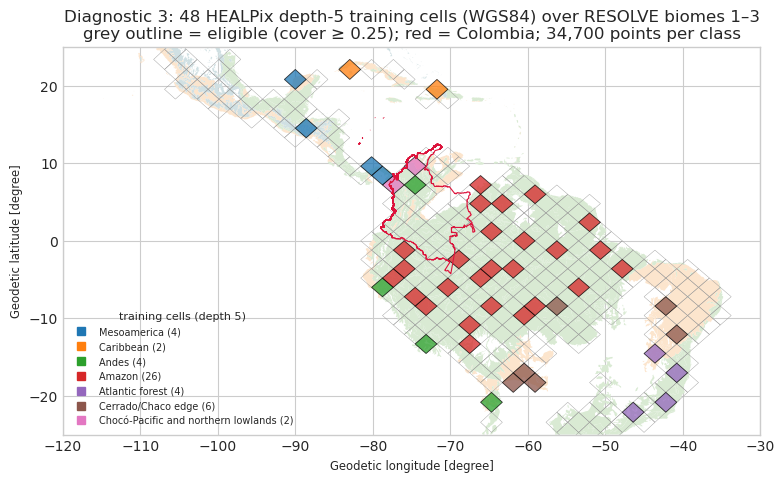

In [16]:
SUB_COLORS = dict(zip(SUBREGIONS, plt.get_cmap("tab10").colors))


def cell_polys(ids: np.ndarray) -> list[np.ndarray]:
    lo, la = vertices(ids.astype("uint64"), CELL_DEPTH, ellipsoid="WGS84")
    lo = (np.asarray(lo) + 180) % 360 - 180
    return [np.column_stack([a, b]) for a, b in zip(lo, np.asarray(la))]


fig, ax = plt.subplots(figsize=(9, 7))
eco.plot(ax=ax, color=eco.BIOME_NUM.map({1: "#d9ead3", 2: "#fce5cd", 3: "#d0e0e3"}), linewidth=0)
elig = cells[cells.eligible & ~cells.selected]
ax.add_collection(PolyCollection(cell_polys(elig.index.to_numpy()), facecolor="none", edgecolor="0.6", linewidth=0.3))
ax.add_collection(PolyCollection(cell_polys(sel.index.to_numpy()), facecolor=[SUB_COLORS[s] for s in sel.subregion],
                                 edgecolor="k", linewidth=0.6, alpha=0.75))
gpd.GeoSeries([COL_GEOM]).boundary.plot(ax=ax, color="crimson", linewidth=0.8)
for s, c in SUB_COLORS.items():
    ax.plot([], [], "s", color=c, label=f"{s} ({int((sel.subregion == s).sum())})")
ax.legend(fontsize=7, loc="lower left", title="training cells (depth 5)", title_fontsize=8)
ax.set_xlim(REGION_BBOX[0], REGION_BBOX[2])
ax.set_ylim(REGION_BBOX[1], REGION_BBOX[3])
ax.set_aspect("equal")
ax.set_title(f"Diagnostic 3: {len(sel)} HEALPix depth-5 training cells (WGS84) over RESOLVE biomes 1–3\n"
             f"grey outline = eligible (cover ≥ {MIN_COVER}); red = Colombia; {n_bal:,} points per class")
fig.savefig(FIGURES / "diag3_training_cells.png", dpi=150, bbox_inches="tight")
plt.show()